In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# --- Fermi-Dirac Mask Components ---
class FermiMask(nn.Module):
    def __init__(self, shape, init_mu=0.0, init_T=1.0):
        super().__init__()
        # mu: learnable cutoff parameter
        self.mu = nn.Parameter(torch.full(shape, init_mu))
        # T: temperature scalar (can be per-layer or global)
        self.register_buffer('T', torch.tensor(init_T))

    def forward(self, w):
        # compute retention probability P(w) = 1/(exp((|w|-mu)/T)+1)
        return 1.0 / (torch.exp((w.abs() - self.mu) / self.T) + 1)

    def set_temperature(self, T_new):
        self.T.fill_(T_new)

# --- Fermi-Gated Linear Layer ---
class FermiGatedLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True, init_mu=0.0, init_T=1.0):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.mask = FermiMask(self.linear.weight.shape, init_mu, init_T)

    def forward(self, x):
        P = self.mask(self.linear.weight)
        w_tilde = P * self.linear.weight
        return F.linear(x, w_tilde, self.linear.bias)

# --- Simple MLP Model with Gating ---
class GatedMLP(nn.Module):
    def __init__(self, input_dim=784, hidden=300, output_dim=10, init_mu=0.0, init_T=1.0):
        super().__init__()
        self.fc1 = FermiGatedLinear(input_dim, hidden, init_mu=init_mu, init_T=init_T)
        self.fc2 = FermiGatedLinear(hidden, output_dim, init_mu=init_mu, init_T=init_T)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# --- Training & Annealing Utilities ---

def train(model, device, train_loader, optimizer, epoch, lambda_sparsity):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        # sparsity penalty: sum of mask probabilities
        sparsity_loss = 0
        for module in model.modules():
            if isinstance(module, FermiMask):
                sparsity_loss += module.forward(module.mu * 0) .sum()
        loss += lambda_sparsity * sparsity_loss
        loss.backward()
        optimizer.step()


def test(model, device, test_loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            pred = model(data).argmax(dim=1)
            correct += pred.eq(target).sum().item()
    return correct / len(test_loader.dataset)

# --- Experiment Setup ---

def run_experiment(epochs=20, init_T=1.0, final_T=0.1, lambda_sparsity=1e-5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # Data
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_loader = DataLoader(datasets.MNIST('.', train=True, download=True, transform=transform), batch_size=64, shuffle=True)
    test_loader  = DataLoader(datasets.MNIST('.', train=False, transform=transform), batch_size=1000)

    # Model
    model = GatedMLP(init_mu=0.0, init_T=init_T).to(device)
    init_mu = model.fc1.linear.weight.data.abs().median().item()
    model.fc1.mask.mu.data.fill_(init_mu)
    model.fc2.mask.mu.data.fill_(init_mu)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Temperature schedule
    for epoch in range(1, epochs+1):
        # linear annealing of T
        T_current = init_T + (final_T - init_T) * (epoch-1)/(epochs-1)
        for module in model.modules():
            if isinstance(module, FermiMask):
                module.set_temperature(T_current)

        train(model, device, train_loader, optimizer, epoch, lambda_sparsity)
        acc = test(model, device, test_loader)
        print(f'Epoch {epoch}: T={T_current:.4f}, Test Accuracy={acc*100:.2f}%')

    # Final hard pruning
    """
    with torch.no_grad():
        total, kept = 0, 0
        for module in model.modules():
            if isinstance(module, FermiMask):
                P = module(module.mu * 0 + module.mu)  # P at |w|=mu gives ~0.5 threshold
                kept += (P > 0.5).sum().item()
                total += P.numel()
        print(f'Final sparsity: kept {kept}/{total} ({kept/total*100:.2f}%)')
    """
        # Final hard pruning (correctly using each layer’s weights)
    with torch.no_grad():
        total, kept = 0, 0
        # iterate over your gated layers directly
        for layer in [model.fc1, model.fc2]:
            W = layer.linear.weight       # the actual weight tensor
            P = layer.mask(W)             # compute the mask on W
            kept += (P > 0.5).sum().item()
            total += P.numel()
        print(f'Final sparsity: kept {kept}/{total} ({kept/total*100:.2f}%)')


if __name__ == '__main__':
    run_experiment(final_T=0.1, lambda_sparsity=1e-5)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.5MB/s]


Epoch 1: T=1.0000, Test Accuracy=95.45%
Epoch 2: T=0.9526, Test Accuracy=96.82%
Epoch 3: T=0.9053, Test Accuracy=97.34%
Epoch 4: T=0.8579, Test Accuracy=97.74%
Epoch 5: T=0.8105, Test Accuracy=97.97%
Epoch 6: T=0.7632, Test Accuracy=97.98%
Epoch 7: T=0.7158, Test Accuracy=98.20%
Epoch 8: T=0.6684, Test Accuracy=98.10%
Epoch 9: T=0.6211, Test Accuracy=98.15%
Epoch 10: T=0.5737, Test Accuracy=98.21%
Epoch 11: T=0.5263, Test Accuracy=98.23%
Epoch 12: T=0.4789, Test Accuracy=98.26%
Epoch 13: T=0.4316, Test Accuracy=98.25%
Epoch 14: T=0.3842, Test Accuracy=98.27%
Epoch 15: T=0.3368, Test Accuracy=98.26%
Epoch 16: T=0.2895, Test Accuracy=98.34%
Epoch 17: T=0.2421, Test Accuracy=98.27%
Epoch 18: T=0.1947, Test Accuracy=98.20%
Epoch 19: T=0.1474, Test Accuracy=98.03%
Epoch 20: T=0.1000, Test Accuracy=97.98%
Final sparsity: kept 1928/238200 (0.81%)


100%|██████████| 9.91M/9.91M [00:00<00:00, 59.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.38MB/s]


Epoch 1: T=1.000, Acc=95.21%, Sparsity=23.32%
Epoch 2: T=0.953, Acc=97.08%, Sparsity=20.32%
Epoch 3: T=0.905, Acc=97.36%, Sparsity=18.70%
Epoch 4: T=0.858, Acc=97.60%, Sparsity=17.38%
Epoch 5: T=0.811, Acc=97.66%, Sparsity=16.13%
Epoch 6: T=0.763, Acc=97.82%, Sparsity=15.35%
Epoch 7: T=0.716, Acc=98.09%, Sparsity=14.70%
Epoch 8: T=0.668, Acc=97.90%, Sparsity=14.18%
Epoch 9: T=0.621, Acc=98.04%, Sparsity=13.62%
Epoch 10: T=0.574, Acc=98.14%, Sparsity=13.20%
Epoch 11: T=0.526, Acc=98.08%, Sparsity=12.82%
Epoch 12: T=0.479, Acc=98.06%, Sparsity=12.55%
Epoch 13: T=0.432, Acc=98.03%, Sparsity=12.32%
Epoch 14: T=0.384, Acc=98.05%, Sparsity=12.00%
Epoch 15: T=0.337, Acc=98.12%, Sparsity=11.81%
Epoch 16: T=0.289, Acc=98.04%, Sparsity=11.66%
Epoch 17: T=0.242, Acc=98.10%, Sparsity=11.56%
Epoch 18: T=0.195, Acc=98.19%, Sparsity=11.48%
Epoch 19: T=0.147, Acc=97.98%, Sparsity=11.79%
Epoch 20: T=0.100, Acc=98.23%, Sparsity=14.01%


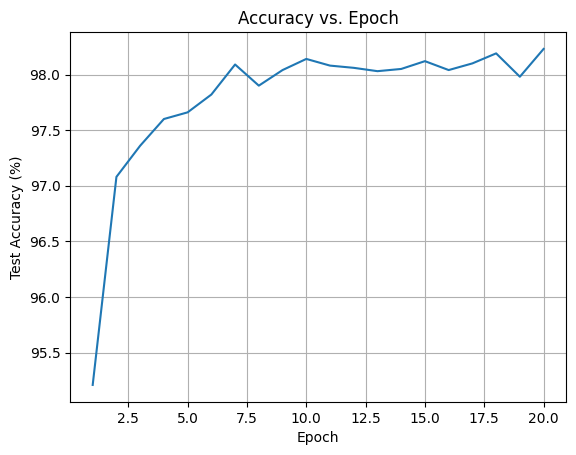

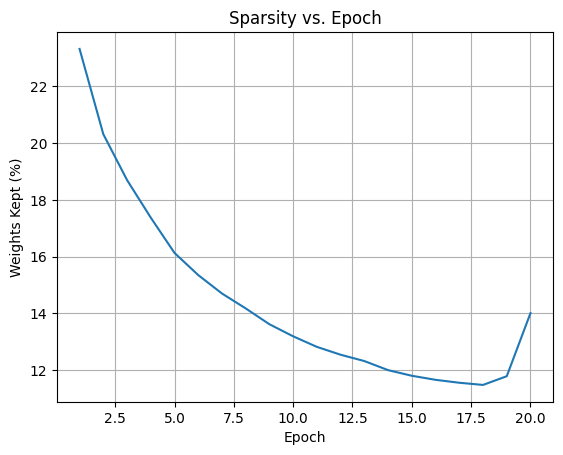

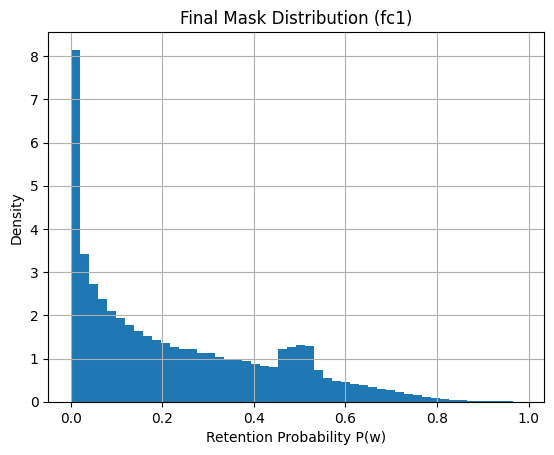

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Re-define components (as in your script)
class FermiMask(nn.Module):
    def __init__(self, shape, init_mu=0.0, init_T=1.0):
        super().__init__()
        self.mu = nn.Parameter(torch.full(shape, init_mu))
        self.register_buffer('T', torch.tensor(init_T))
    def forward(self, w):
        return 1.0 / (torch.exp((w.abs() - self.mu) / self.T) + 1)
    def set_temperature(self, T_new):
        self.T.fill_(T_new)

class FermiGatedLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True, init_mu=0.0, init_T=1.0):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.mask = FermiMask(self.linear.weight.shape, init_mu, init_T)
    def forward(self, x):
        P = self.mask(self.linear.weight)
        w_tilde = P * self.linear.weight
        return F.linear(x, w_tilde, self.linear.bias), P.sum().item()

class GatedMLP(nn.Module):
    def __init__(self, input_dim=784, hidden=300, output_dim=10, init_mu=0.0, init_T=1.0):
        super().__init__()
        self.fc1 = FermiGatedLinear(input_dim, hidden, init_mu=init_mu, init_T=init_T)
        self.fc2 = FermiGatedLinear(hidden, output_dim, init_mu=init_mu, init_T=init_T)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x, sp1 = self.fc1(x)
        x = F.relu(x)
        x, sp2 = self.fc2(x)
        return x, sp1 + sp2

def train(model, device, train_loader, optimizer, lambda_sparsity):
    model.train()
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output, sparsity_sum = model(data)
        loss = F.cross_entropy(output, target) + lambda_sparsity * sparsity_sum
        loss.backward()
        optimizer.step()

def test(model, device, test_loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output, _ = model(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
    return correct / len(test_loader.dataset)

# Experiment
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_loader = DataLoader(datasets.MNIST('.', train=True, download=True, transform=transform),
                          batch_size=64, shuffle=True)
test_loader = DataLoader(datasets.MNIST('.', train=False, transform=transform), batch_size=1000)

# Hyperparams
epochs = 20
init_T = 1.0
final_T = 0.1
lambda_sparsity = 1e-5

# Model
model = GatedMLP(init_mu=0.0, init_T=init_T).to(device)
# Initialize mu to median of weights
init_mu_val = model.fc1.linear.weight.data.abs().median().item()
model.fc1.mask.mu.data.fill_(init_mu_val)
model.fc2.mask.mu.data.fill_(init_mu_val)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Storage
accuracy = []
sparsity = []
temperatures = []

# Training loop with recording
for epoch in range(1, epochs + 1):
    # Anneal temperature
    T_current = init_T + (final_T - init_T) * (epoch-1)/(epochs-1)
    for module in model.modules():
        if isinstance(module, FermiMask):
            module.set_temperature(T_current)
    temperatures.append(T_current)

    train(model, device, train_loader, optimizer, lambda_sparsity)
    acc = test(model, device, test_loader)

    # Compute current sparsity (fraction kept)
    with torch.no_grad():
        total = 0
        kept = 0
        for layer in [model.fc1, model.fc2]:
            W = layer.linear.weight
            P = layer.mask(W)
            total += P.numel()
            kept += (P > 0.5).sum().item()
        sparsity.append(kept/total)

    accuracy.append(acc)
    print(f'Epoch {epoch}: T={T_current:.3f}, Acc={acc*100:.2f}%, Sparsity={sparsity[-1]*100:.2f}%')

# Plotting
plt.figure()
plt.plot(range(1, epochs+1), [a*100 for a in accuracy])
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Accuracy vs. Epoch')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(range(1, epochs+1), [s*100 for s in sparsity])
plt.xlabel('Epoch')
plt.ylabel('Weights Kept (%)')
plt.title('Sparsity vs. Epoch')
plt.grid(True)
plt.show()

# Final mask distribution
with torch.no_grad():
    W = model.fc1.linear.weight
    P = model.fc1.mask(W).cpu().numpy().flatten()
plt.figure()
plt.hist(P, bins=50, density=True)
plt.xlabel('Retention Probability P(w)')
plt.ylabel('Density')
plt.title('Final Mask Distribution (fc1)')
plt.grid(True)
plt.show()


Epoch 1: T=1.000, Acc=95.42%, Sparsity=22.44%
Epoch 2: T=0.953, Acc=96.81%, Sparsity=19.95%
Epoch 3: T=0.905, Acc=97.24%, Sparsity=18.23%
Epoch 4: T=0.858, Acc=97.84%, Sparsity=16.96%
Epoch 5: T=0.811, Acc=97.62%, Sparsity=15.88%
Epoch 6: T=0.763, Acc=98.05%, Sparsity=15.02%
Epoch 7: T=0.716, Acc=98.00%, Sparsity=14.32%
Epoch 8: T=0.668, Acc=97.90%, Sparsity=13.78%
Epoch 9: T=0.621, Acc=98.00%, Sparsity=13.25%
Epoch 10: T=0.574, Acc=97.90%, Sparsity=12.90%
Epoch 11: T=0.526, Acc=97.64%, Sparsity=12.52%
Epoch 12: T=0.479, Acc=98.12%, Sparsity=12.18%
Epoch 13: T=0.432, Acc=97.93%, Sparsity=11.97%
Epoch 14: T=0.384, Acc=98.07%, Sparsity=11.69%
Epoch 15: T=0.337, Acc=98.16%, Sparsity=11.51%
Epoch 16: T=0.289, Acc=97.98%, Sparsity=11.44%
Epoch 17: T=0.242, Acc=98.02%, Sparsity=11.24%
Epoch 18: T=0.195, Acc=98.07%, Sparsity=11.22%
Epoch 19: T=0.147, Acc=98.17%, Sparsity=11.53%
Epoch 20: T=0.100, Acc=98.16%, Sparsity=13.95%


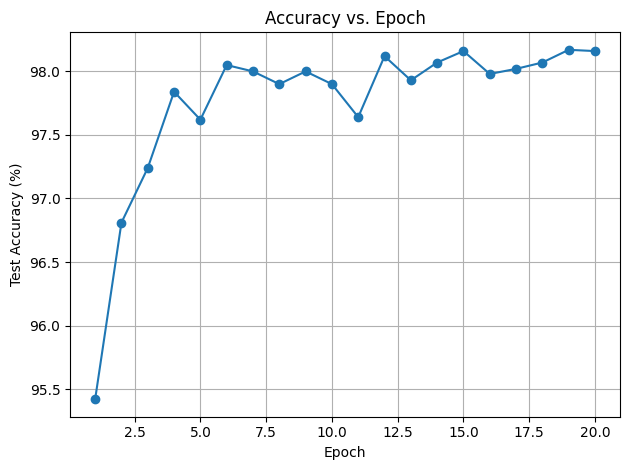

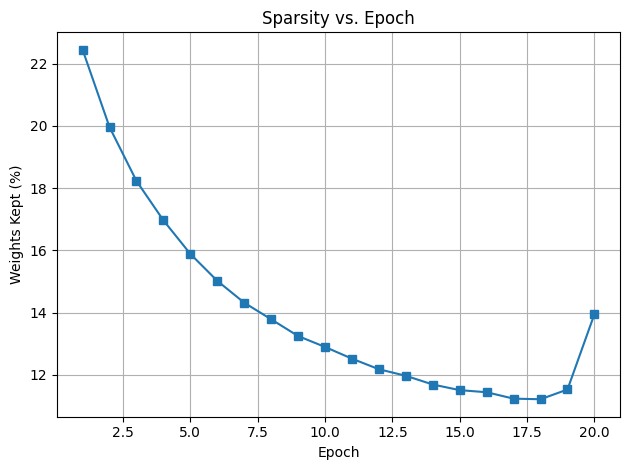

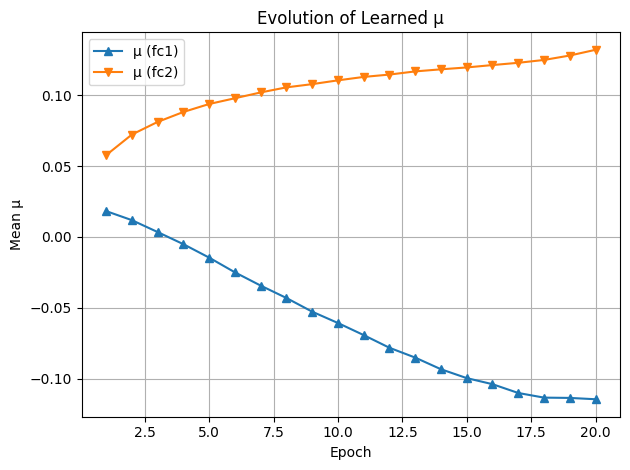

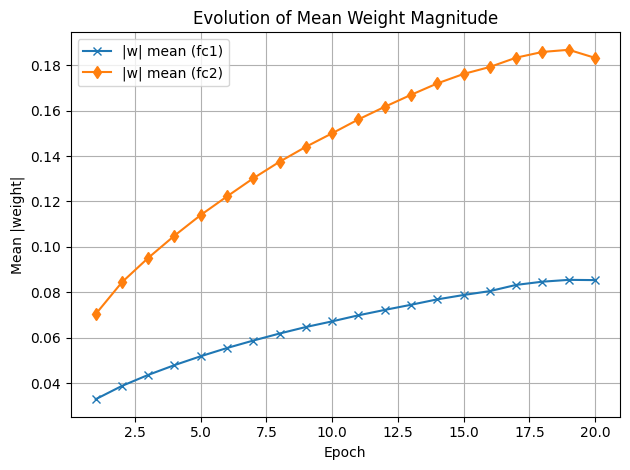

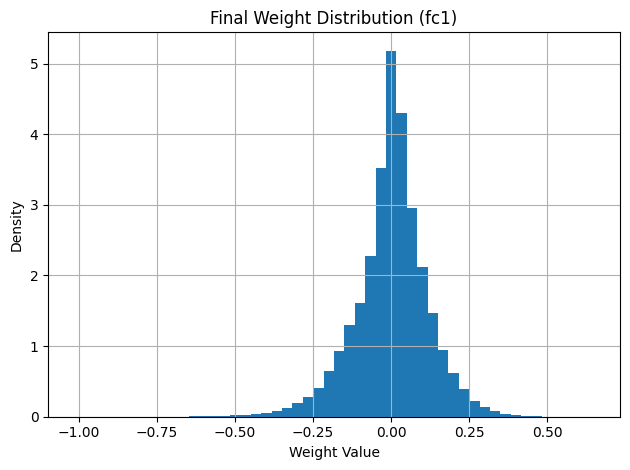

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --- Fermi-Dirac Mask Components ---
class FermiMask(nn.Module):
    def __init__(self, shape, init_mu=0.0, init_T=1.0):
        super().__init__()
        self.mu = nn.Parameter(torch.full(shape, init_mu))
        self.register_buffer('T', torch.tensor(init_T))
    def forward(self, w):
        return 1.0 / (torch.exp((w.abs() - self.mu) / self.T) + 1)
    def set_temperature(self, T_new):
        self.T.fill_(T_new)

# --- Fermi-Gated Linear Layer ---
class FermiGatedLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True, init_mu=0.0, init_T=1.0):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.mask = FermiMask(self.linear.weight.shape, init_mu, init_T)
    def forward(self, x):
        P = self.mask(self.linear.weight)
        w_tilde = P * self.linear.weight
        return F.linear(x, w_tilde, self.linear.bias), P.sum().item()

# --- Simple MLP Model with Gating ---
class GatedMLP(nn.Module):
    def __init__(self, input_dim=784, hidden=300, output_dim=10, init_mu=0.0, init_T=1.0):
        super().__init__()
        self.fc1 = FermiGatedLinear(input_dim, hidden, init_mu=init_mu, init_T=init_T)
        self.fc2 = FermiGatedLinear(hidden, output_dim, init_mu=init_mu, init_T=init_T)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x, sp1 = self.fc1(x)
        x = F.relu(x)
        x, sp2 = self.fc2(x)
        return x, sp1 + sp2

# --- Training & Testing Utilities ---
def train(model, device, train_loader, optimizer, lambda_sparsity):
    model.train()
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output, sparsity_sum = model(data)
        loss = F.cross_entropy(output, target) + lambda_sparsity * sparsity_sum
        loss.backward()
        optimizer.step()

def test(model, device, test_loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output, _ = model(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
    return correct / len(test_loader.dataset)

# --- Experiment Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_loader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=64, shuffle=True
)
test_loader = DataLoader(
    datasets.MNIST('.', train=False, transform=transform),
    batch_size=1000
)

# --- Hyperparameters ---
epochs = 20
init_T = 1.0
final_T = 0.1
lambda_sparsity = 1e-5

# --- Model Initialization ---
model = GatedMLP(init_mu=0.0, init_T=init_T).to(device)
# Initialize μ to median of initial weights
init_mu_val = model.fc1.linear.weight.data.abs().median().item()
model.fc1.mask.mu.data.fill_(init_mu_val)
model.fc2.mask.mu.data.fill_(init_mu_val)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# --- Recording Lists ---
accuracy = []
sparsity = []
temperatures = []
mu_fc1 = []
mu_fc2 = []
weight_mean_fc1 = []
weight_mean_fc2 = []

# --- Training Loop with Recording ---
for epoch in range(1, epochs + 1):
    # Anneal temperature
    T_current = init_T + (final_T - init_T) * (epoch - 1) / (epochs - 1)
    for module in model.modules():
        if isinstance(module, FermiMask):
            module.set_temperature(T_current)
    temperatures.append(T_current)

    train(model, device, train_loader, optimizer, lambda_sparsity)
    acc = test(model, device, test_loader)

    # Record metrics
    accuracy.append(acc)
    with torch.no_grad():
        # μ averages
        mu_fc1.append(model.fc1.mask.mu.data.mean().item())
        mu_fc2.append(model.fc2.mask.mu.data.mean().item())
        # Weight magnitude averages
        weight_mean_fc1.append(model.fc1.linear.weight.data.abs().mean().item())
        weight_mean_fc2.append(model.fc2.linear.weight.data.abs().mean().item())
        # Sparsity
        total, kept = 0, 0
        for layer in [model.fc1, model.fc2]:
            W = layer.linear.weight
            P = layer.mask(W)
            total += P.numel()
            kept += (P > 0.5).sum().item()
        sparsity.append(kept / total)

    print(f'Epoch {epoch}: T={T_current:.3f}, Acc={acc*100:.2f}%, Sparsity={sparsity[-1]*100:.2f}%')

# --- Plotting Results ---

# Accuracy vs. Epoch
plt.figure()
plt.plot(range(1, epochs+1), [a*100 for a in accuracy], marker='o')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Accuracy vs. Epoch')
plt.grid(True)
plt.tight_layout()
plt.show()

# Sparsity vs. Epoch
plt.figure()
plt.plot(range(1, epochs+1), [s*100 for s in sparsity], marker='s')
plt.xlabel('Epoch')
plt.ylabel('Weights Kept (%)')
plt.title('Sparsity vs. Epoch')
plt.grid(True)
plt.tight_layout()
plt.show()

# Learned μ vs. Epoch
plt.figure()
plt.plot(range(1, epochs+1), mu_fc1, marker='^', label='μ (fc1)')
plt.plot(range(1, epochs+1), mu_fc2, marker='v', label='μ (fc2)')
plt.xlabel('Epoch')
plt.ylabel('Mean μ')
plt.title('Evolution of Learned μ')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Mean Weight Magnitude vs. Epoch
plt.figure()
plt.plot(range(1, epochs+1), weight_mean_fc1, marker='x', label='|w| mean (fc1)')
plt.plot(range(1, epochs+1), weight_mean_fc2, marker='d', label='|w| mean (fc2)')
plt.xlabel('Epoch')
plt.ylabel('Mean |weight|')
plt.title('Evolution of Mean Weight Magnitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Final Weight Distribution (fc1)
with torch.no_grad():
    final_weights_fc1 = model.fc1.linear.weight.cpu().numpy().flatten()
plt.figure()
plt.hist(final_weights_fc1, bins=50, density=True)
plt.xlabel('Weight Value')
plt.ylabel('Density')
plt.title('Final Weight Distribution (fc1)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Compute average μ across layers
M = [(m1 + m2) / 2 for m1, m2 in zip(mu_fc1, mu_fc2)]

# Prepare arrays
T_arr = np.array(temperatures)
M_arr = np.array(M)
acc_arr = np.array(accuracy) * 100        # %
spars_arr = np.array(sparsity) * 100      # %

# 3D scatter: x=T, y=M, z=Accuracy, color=Sparsity
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    T_arr, M_arr, acc_arr,
    c=spars_arr,
    marker='o',
    cmap=plt.cm.viridis
)

ax.set_xlabel('Temperature (T)')
ax.set_ylabel('Mean μ (M)')
ax.set_zlabel('Accuracy (%)')
ax.set_title('T vs. M vs. Accuracy; Color = Sparsity (%)')

# Colorbar for sparsity
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_label('Sparsity (%)')

plt.tight_layout()
plt.show()


NameError: name 'mu_fc1' is not defined

In [ ]:
from graphviz import Digraph

flow = Digraph('Fermi-Pruning-Flow', format='png')
flow.attr(rankdir='LR', size='10,6', fontsize='12')

# Start and end
flow.node('start', 'Start', shape='oval')
flow.node('end', 'End', shape='oval')

# Initialization
flow.node('init', 'Initialize Model\n• GatedMLP\n• FermiMask', shape='box')

# μ and T setup
flow.node('setup', 'Set μ (median of |w|)\nSet T = init_T', shape='box')

# Epoch loop
flow.node('loop', 'Epoch Loop\nfor epoch in 1..E', shape='diamond')

# Per-epoch steps
flow.node('anneal', 'Anneal Temperature T', shape='box')
flow.node('train', 'Train Step\n• Compute P(w)\n• Mask weights\n• Forward + Backward\n• Update w, μ', shape='box')
flow.node('test', 'Test Step\nCompute Accuracy', shape='box')
flow.node('record', 'Record Metrics\n• Accuracy\n• Sparsity\n• μ, |w|, T', shape='box')

# Plotting
flow.node('plot', 'Plot Results\n• Accuracy vs Epoch\n• Sparsity vs Epoch\n• μ evolution\n• Weight distribution', shape='box')

# Edges
flow.edge('start', 'init')
flow.edge('init', 'setup')
flow.edge('setup', 'loop')

flow.edge('loop', 'anneal', label='Yes')
flow.edge('anneal', 'train')
flow.edge('train', 'test')
flow.edge('test', 'record')
flow.edge('record', 'loop')

flow.edge('loop', 'plot', label='No')
flow.edge('plot', 'end')

# Render to file
flow.render('fermi_pruning_flowchart')


'fermi_pruning_flowchart.png'

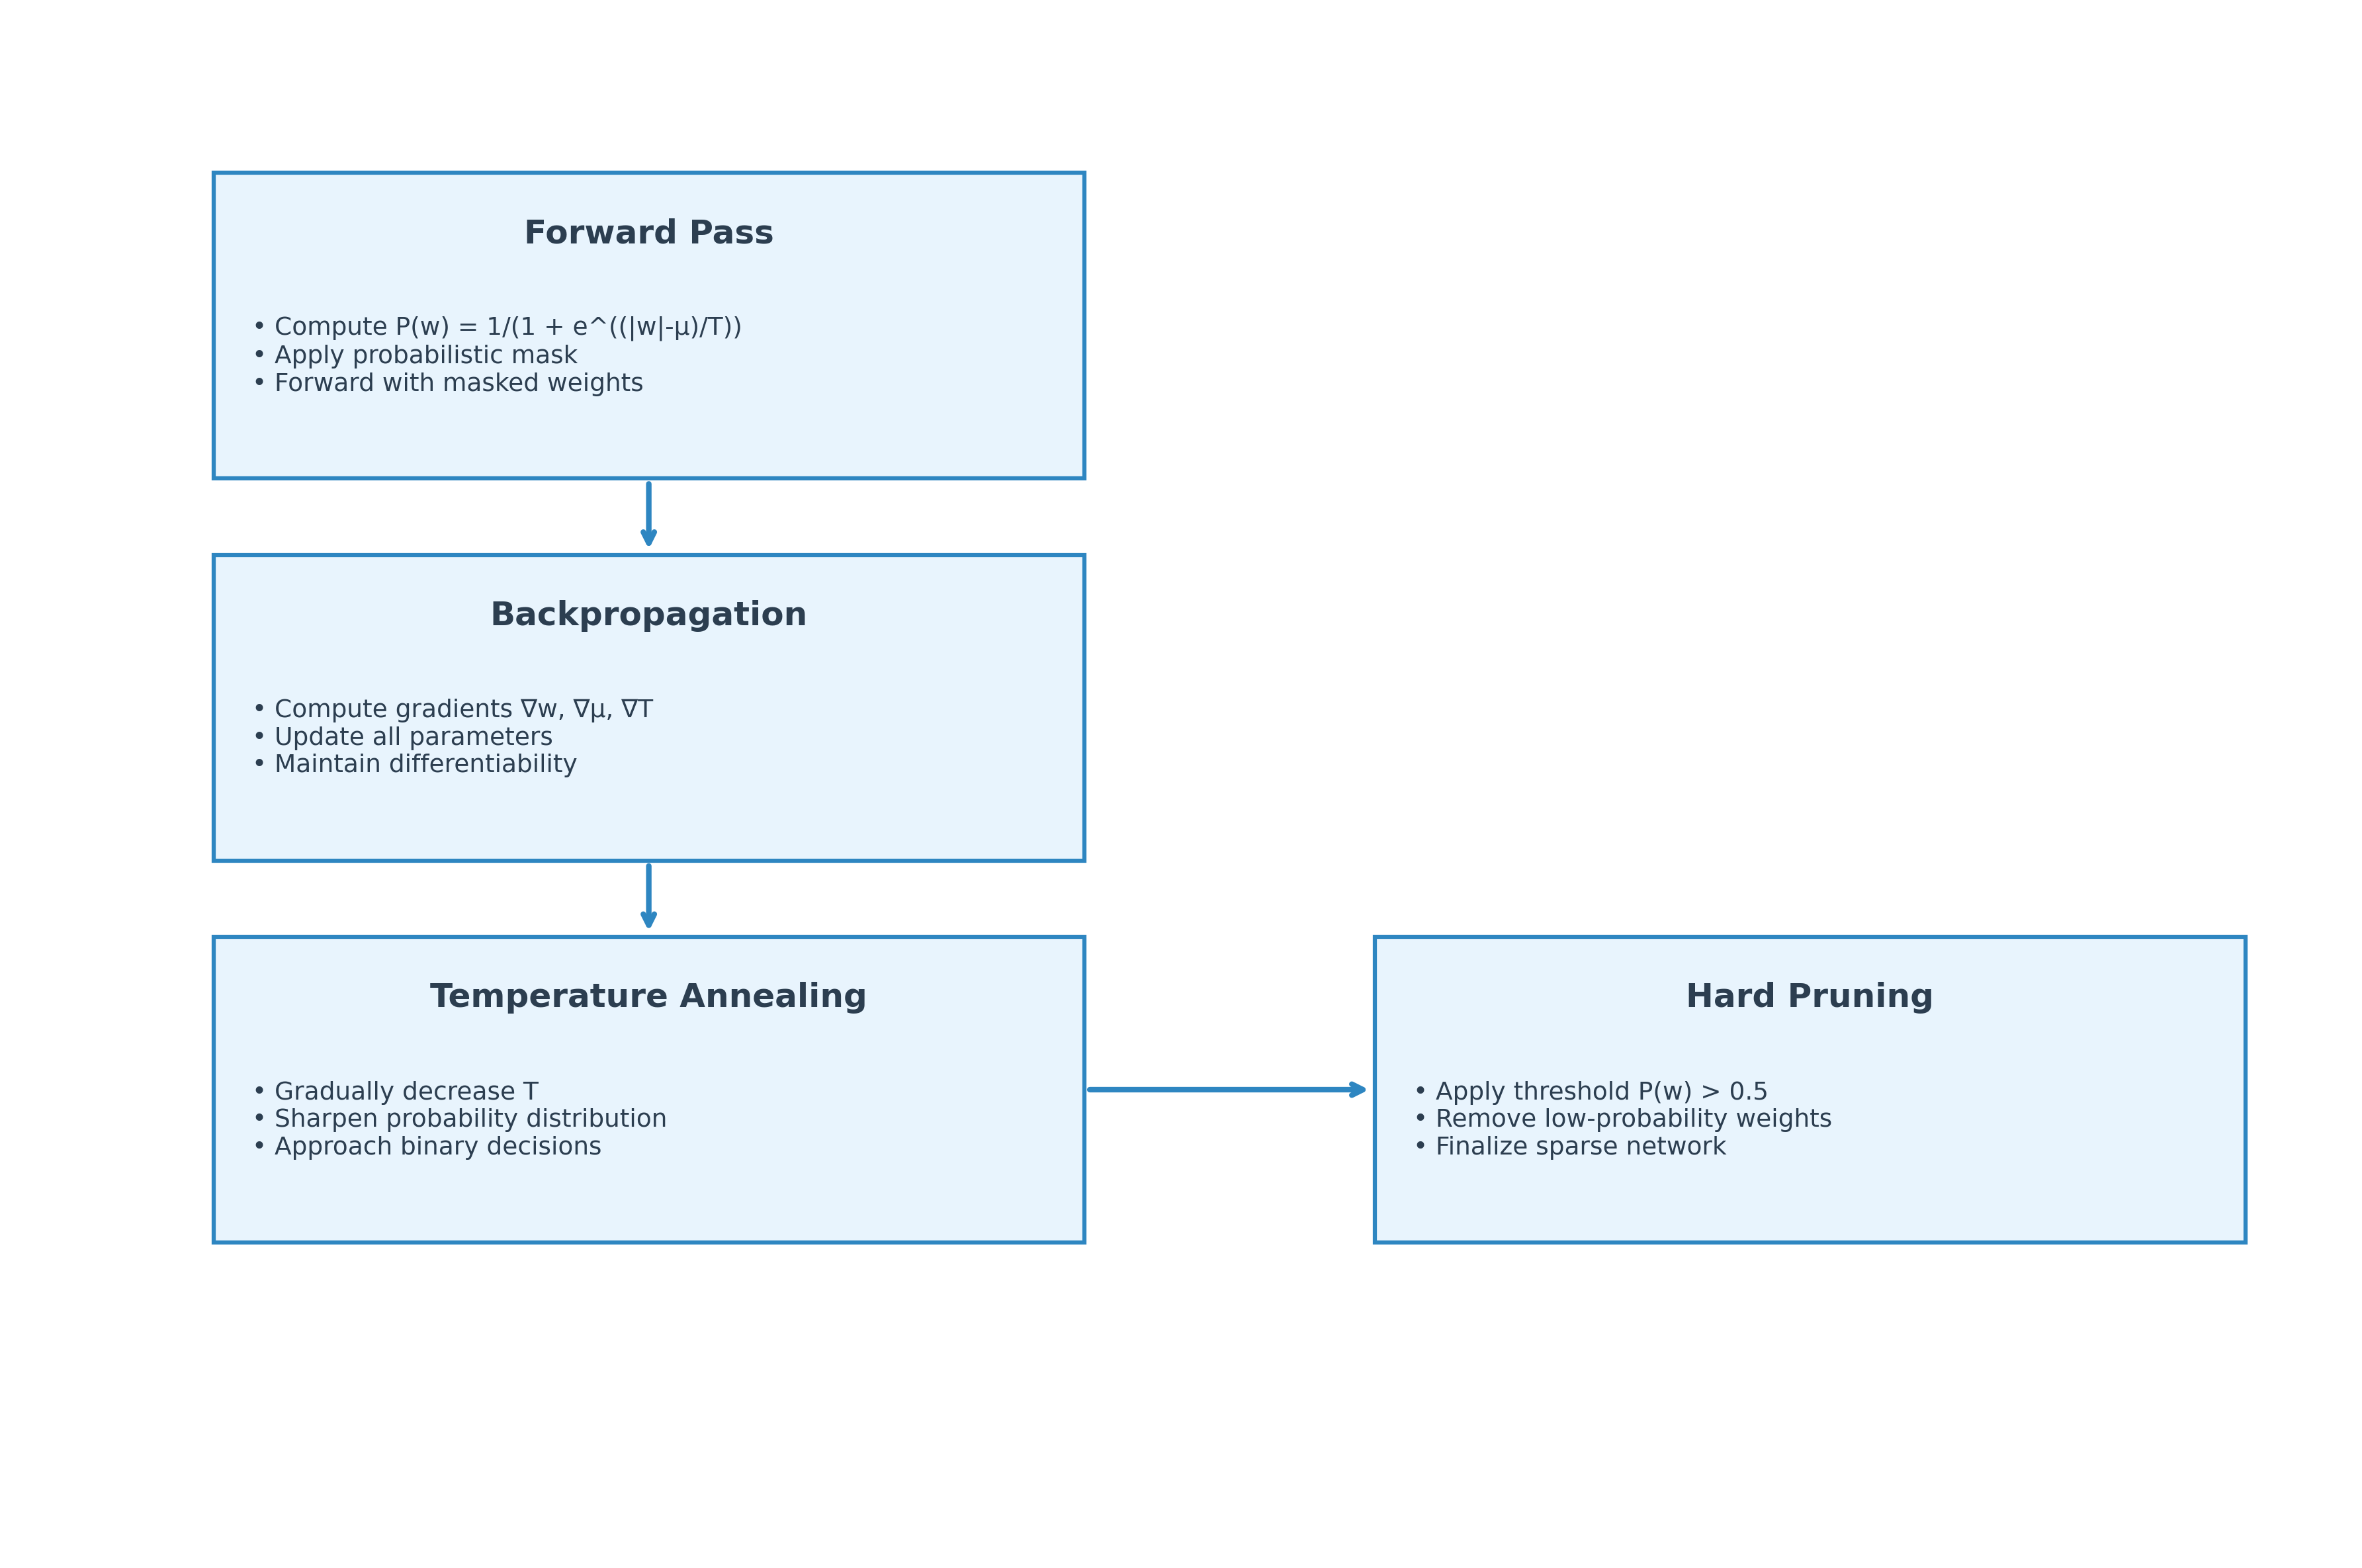

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create figure with clean proportions
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis('off')

# Simple, clean color scheme
block_color = '#E8F4FD'
border_color = '#2E86C1'
text_color = '#2C3E50'

# Define blocks with better content organization
blocks = [
    {
        'xy': (1, 7),
        'text': 'Forward Pass',
        'details': '• Compute P(w) = 1/(1 + e^((|w|-μ)/T))\n• Apply probabilistic mask\n• Forward with masked weights'
    },
    {
        'xy': (1, 4.5),
        'text': 'Backpropagation',
        'details': '• Compute gradients ∇w, ∇μ, ∇T\n• Update all parameters\n• Maintain differentiability'
    },
    {
        'xy': (1, 2),
        'text': 'Temperature Annealing',
        'details': '• Gradually decrease T\n• Sharpen probability distribution\n• Approach binary decisions'
    },
    {
        'xy': (7, 2),
        'text': 'Hard Pruning',
        'details': '• Apply threshold P(w) > 0.5\n• Remove low-probability weights\n• Finalize sparse network'
    }
]

# Draw clean, simple blocks
for block in blocks:
    x, y = block['xy']

    # Main rectangle
    rect = patches.Rectangle(
        (x, y), 4.5, 2,
        linewidth=1.5,
        edgecolor=border_color,
        facecolor=block_color
    )
    ax.add_patch(rect)

    # Title
    ax.text(x + 2.25, y + 1.6, block['text'],
            ha='center', va='center',
            fontsize=12, fontweight='bold',
            color=text_color)

    # Details
    ax.text(x + 0.2, y + 0.8, block['details'],
            ha='left', va='center',
            fontsize=9,
            color=text_color)

# Simple arrows
arrow_style = dict(arrowstyle='->', lw=2, color=border_color)

# Vertical arrows
ax.annotate('', xy=(3.25, 6.5), xytext=(3.25, 7), arrowprops=arrow_style)
ax.annotate('', xy=(3.25, 4), xytext=(3.25, 4.5), arrowprops=arrow_style)

# Horizontal arrow
ax.annotate('', xy=(7, 3), xytext=(5.5, 3), arrowprops=arrow_style)

# Simple title
ax.text(6, 9.5, '',
        ha='center', va='center',
        fontsize=16, fontweight='bold',
        color=text_color)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Define architecture details
architecture = [
    {
        "Layer": "Input",
        "Type": "Flatten",
        "Input Shape": "(batch_size, 1, 28, 28)",
        "Output Shape": "(batch_size, 784)",
        "Parameters": 0
    },
    {
        "Layer": "fc1",
        "Type": "FermiGatedLinear",
        "Input Shape": "(batch_size, 784)",
        "Output Shape": "(batch_size, 300)",
        "Parameters": 784 * 300 + 300  # weights + bias
    },
    {
        "Layer": "mask1 (μ)",
        "Type": "FermiMask",
        "Input Shape": "(300 weights per neuron)",
        "Output Shape": "(300 retention params)",
        "Parameters": 784 * 300  # mu parameters
    },
    {
        "Layer": "fc2",
        "Type": "FermiGatedLinear",
        "Input Shape": "(batch_size, 300)",
        "Output Shape": "(batch_size, 10)",
        "Parameters": 300 * 10 + 10  # weights + bias
    },
    {
        "Layer": "mask2 (μ)",
        "Type": "FermiMask",
        "Input Shape": "(10 weights per neuron)",
        "Output Shape": "(10 retention params)",
        "Parameters": 300 * 10  # mu parameters
    },
    {
        "Layer": "Output",
        "Type": "Softmax/CrossEntropy",
        "Input Shape": "(batch_size, 10)",
        "Output Shape": "(batch_size, 10)",
        "Parameters": 0
    }
]

df = pd.DataFrame(architecture)

import ace_tools as tools; tools.display_dataframe_to_user(name="MLP Architecture", dataframe=df)


,Layer,Type,Input Shape,Output Shape,Parameters
0,Input,Flatten,"(batch_size, 1, 28, 28)","(batch_size, 784)",0
1,fc1,FermiGatedLinear,"(batch_size, 784)","(batch_size, 300)",235500
2,mask1 (μ),FermiMask,(300 weights per neuron),(300 retention params),235200
3,fc2,FermiGatedLinear,"(batch_size, 300)","(batch_size, 10)",3010
4,mask2 (μ),FermiMask,(10 weights per neuron),(10 retention params),3000
5,Output,Softmax/CrossEntropy,"(batch_size, 10)","(batch_size, 10)",0


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

# --- Define Fermi-pruned CNN and Baseline CNN as before ---
class FermiMask(nn.Module):
    def __init__(self, shape, init_mu=0.0, init_T=1.0):
        super().__init__()
        self.mu = nn.Parameter(torch.full(shape, init_mu))
        self.register_buffer('T', torch.tensor(init_T))
    def forward(self, w):
        return 1.0 / (torch.exp((w.abs() - self.mu) / self.T) + 1)
    def set_temperature(self, T_new):
        self.T.fill_(T_new)

class FermiGatedConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, padding=0, init_mu=0.0, init_T=1.0):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, padding=padding)
        self.mask = FermiMask(self.conv.weight.shape, init_mu, init_T)
    def forward(self, x):
        P = self.mask(self.conv.weight)
        w_tilde = P * self.conv.weight
        return F.conv2d(x, w_tilde, self.conv.bias, padding=self.conv.padding), P

class FermiPrunedCNN(nn.Module):
    def __init__(self, init_mu=0.0, init_T=1.0):
        super().__init__()
        self.conv1 = FermiGatedConv(3, 32, 3, padding=1, init_mu=init_mu, init_T=init_T)
        self.conv2 = FermiGatedConv(32, 64, 3, padding=1, init_mu=init_mu, init_T=init_T)
        self.fc1   = nn.Linear(64*8*8, 256)
        self.fc2   = nn.Linear(256, 10)
    def forward(self, x):
        x, P1 = self.conv1(x); x = F.relu(F.max_pool2d(x, 2))
        x, P2 = self.conv2(x); x = F.relu(F.max_pool2d(x, 2))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x), P1, P2

class SmallCNN(nn.Module):
    def __init__(self, c1_out, c2_out):
        super().__init__()
        self.conv1 = nn.Conv2d(3, c1_out, 3, padding=1)
        self.conv2 = nn.Conv2d(c1_out, c2_out, 3, padding=1)
        self.fc1   = nn.Linear(c2_out*8*8, 256)
        self.fc2   = nn.Linear(256, 10)
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


# --- Define FermiMask, FermiGatedConv, FermiPrunedCNN, SmallCNN, BaselineCNN as before ---

# Training utilities with layer‑wise λ
def train_epoch(model, device, loader, optimizer, lambda1=0.0, lambda2=0.0):
    model.train()
    start = time.perf_counter()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits, P1, P2 = model(x)
        # layer‑wise sparsity penalty
        loss = F.cross_entropy(logits, y) \
               + lambda1 * P1.mean() \
               + lambda2 * P2.mean()
        loss.backward()
        optimizer.step()
    return time.perf_counter() - start

def test_model(model, device, loader, pruned=False):
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            logits = out[0] if pruned else out
            correct += logits.argmax(dim=1).eq(y).sum().item()
    return correct / len(loader.dataset)

# Main benchmark with one-shot prune & retrain
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.247,0.243,0.261))
])
train_loader = DataLoader(datasets.CIFAR10('.', train=True, download=True, transform=transform),
                          batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(datasets.CIFAR10('.', train=False, transform=transform),
                          batch_size=128, shuffle=False, num_workers=2)

# Hyperparams
epochs1      = 10
epochs2      = 20
init_T, final_T = 1.0, 0.1
base_lambda  = 1e-5
lambda1, lambda2 = 0.3 * base_lambda, base_lambda   # weaker penalty on conv1

# Phase 1: Train Fermi‑pruned CNN
#  μ init: 25th percentile on conv1, median on conv2
temp = BaselineCNN().to(device)
w1 = temp.conv1.weight.data.abs().view(-1)
mu1 = w1.kthvalue(int(0.25 * w1.numel())).values.item()
w2 = temp.conv2.weight.data.abs().view(-1)
mu2 = w2.median().item()

model_pruned = FermiPrunedCNN(init_mu=mu2, init_T=init_T).to(device)
# override only conv1’s μ
model_pruned.conv1.mask.mu.data.fill_(mu1)
opt_pruned = optim.SGD(model_pruned.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

times1 = []
for ep in range(1, epochs1+1):
    # anneal T
    T_cur = init_T + (final_T - init_T)*(ep-1)/(epochs1-1)
    for m in model_pruned.modules():
        if isinstance(m, FermiMask):
            m.set_temperature(T_cur)
    t = train_epoch(model_pruned, device, train_loader, opt_pruned,
                    lambda1=lambda1, lambda2=lambda2)
    times1.append(t)
print("Phase 1 complete")

# Determine surviving filters with max‐criterion
with torch.no_grad():
    P1 = model_pruned.conv1.mask(model_pruned.conv1.conv.weight)  # [out_ch,in_ch,k,k]
    # keep if any weight in the filter has P>0.5
    surv1 = (P1.view(P1.size(0), -1).max(dim=1).values > 0.5).sum().item()
    P2 = model_pruned.conv2.mask(model_pruned.conv2.conv.weight)
    surv2 = (P2.view(P2.size(0), -1).max(dim=1).values > 0.5).sum().item()

print(f"Surviving filters: conv1 -> {surv1}, conv2 -> {surv2}")

# Phase 2: Build smaller CNN and retrain
small = SmallCNN(surv1, surv2).to(device)
opt_small = optim.SGD(small.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

times2 = []
for ep in range(1, epochs2+1):
    t = train_epoch(small, device, train_loader, opt_small)
    times2.append(t)
print("Phase 2 complete")

# Final evaluation
acc_pruned = test_model(model_pruned, device, test_loader, pruned=True)
acc_small  = test_model(small, device, test_loader, pruned=False)

print(f"{'Model':<25}{'Time(min)':<12}{'Test Acc (%)':<12}")
print("-"*50)
print(f"{'Fermi-pruned Phase1':<25}{sum(times1)/60:<12.2f}{acc_pruned*100:<12.2f}")
print(f"{'Small retrained Phase2':<25}{sum(times2)/60:<12.2f}{acc_small*100:<12.2f}")

# Training utilities
def train_epoch(model, device, loader, optimizer, prune_lambda=0.0, pruned=False):
    model.train()
    start = time.perf_counter()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        if pruned:
            logits, P1, P2 = model(x)
            sparsity = P1.mean() + P2.mean()
            loss = F.cross_entropy(logits, y) + prune_lambda * sparsity
        else:
            logits = model(x)
            loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()
    return time.perf_counter() - start

def test_model(model, device, loader, pruned=False):
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            logits = out[0] if pruned else out
            correct += logits.argmax(dim=1).eq(y).sum().item()
    return correct / len(loader.dataset)

# Main benchmark with one-shot prune & retrain
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize((0.4914,0.4822,0.4465),(0.247,0.243,0.261))
])
train_loader = DataLoader(datasets.CIFAR10('.', train=True, download=True, transform=transform),
                          batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(datasets.CIFAR10('.', train=False, transform=transform),
                          batch_size=128, shuffle=False, num_workers=2)

# Hyperparams
epochs1 = 10
epochs2 = 20
init_T, final_T = 1.0, 0.1
prune_lambda = 1e-5

# Phase 1: Train Fermi-pruned CNN for epochs1
# Init mu
temp = BaselineCNN().to(device)
init_mu = temp.conv1.weight.data.abs().median().item()
model_pruned = FermiPrunedCNN(init_mu=init_mu, init_T=init_T).to(device)
opt_pruned = optim.SGD(model_pruned.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

times1 = []
for ep in range(1, epochs1+1):
    T_cur = init_T + (final_T-init_T)*(ep-1)/(epochs1-1)
    for m in model_pruned.modules():
        if isinstance(m, FermiMask):
            m.set_temperature(T_cur)
    t = train_epoch(model_pruned, device, train_loader, opt_pruned, prune_lambda, pruned=True)
    times1.append(t)
print("Phase 1 complete")

# Determine surviving filters per conv layer
with torch.no_grad():
    P1 = model_pruned.conv1.mask(model_pruned.conv1.conv.weight)  # [out_ch, in_ch, k, k]
    surv1 = (P1.mean(dim=(1,2,3)) > 0.5).sum().item()
    P2 = model_pruned.conv2.mask(model_pruned.conv2.conv.weight)
    surv2 = (P2.mean(dim=(1,2,3)) > 0.5).sum().item()

print(f"Surviving filters: conv1 -> {surv1}, conv2 -> {surv2}")

# Phase 2: Build smaller CNN and retrain
small = SmallCNN(surv1, surv2).to(device)
opt_small = optim.SGD(small.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

times2 = []
for ep in range(1, epochs2+1):
    t = train_epoch(small, device, train_loader, opt_small, pruned=False)
    times2.append(t)
print("Phase 2 complete")

# Evaluate both models
acc_pruned = test_model(model_pruned, device, test_loader, pruned=True)
acc_small  = test_model(small, device, test_loader, pruned=False)

print(f"{'Model':<20}{'Time(min)':<12}{'Test Acc (%)':<12}")
print("-"*44)
print(f"{'Fermi-pruned Phase1':<20}{sum(times1)/60:<12.2f}{acc_pruned*100:<12.2f}")
print(f"{'Small retrained Phase2':<20}{sum(times2)/60:<12.2f}{acc_small*100:<12.2f}")



100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


NameError: name 'BaselineCNN' is not defined